## 1. Get image lists

In [2]:
import os
import glob
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt


In [10]:
folder_path = "/mnt/c/Users/Admin/Downloads/archive/animals/animals"
list_animals = []
animal_images = {}
list_images = []

for animal in os.listdir(folder_path): 
  path = os.path.join(folder_path, animal)
  image_list = glob.glob(path + "/**/*.jpg", recursive=True )

  list_animals.append(animal)
  animal_images[animal] = image_list
  list_images.extend(image_list)

Num of images:  5400
Num of animals:  90


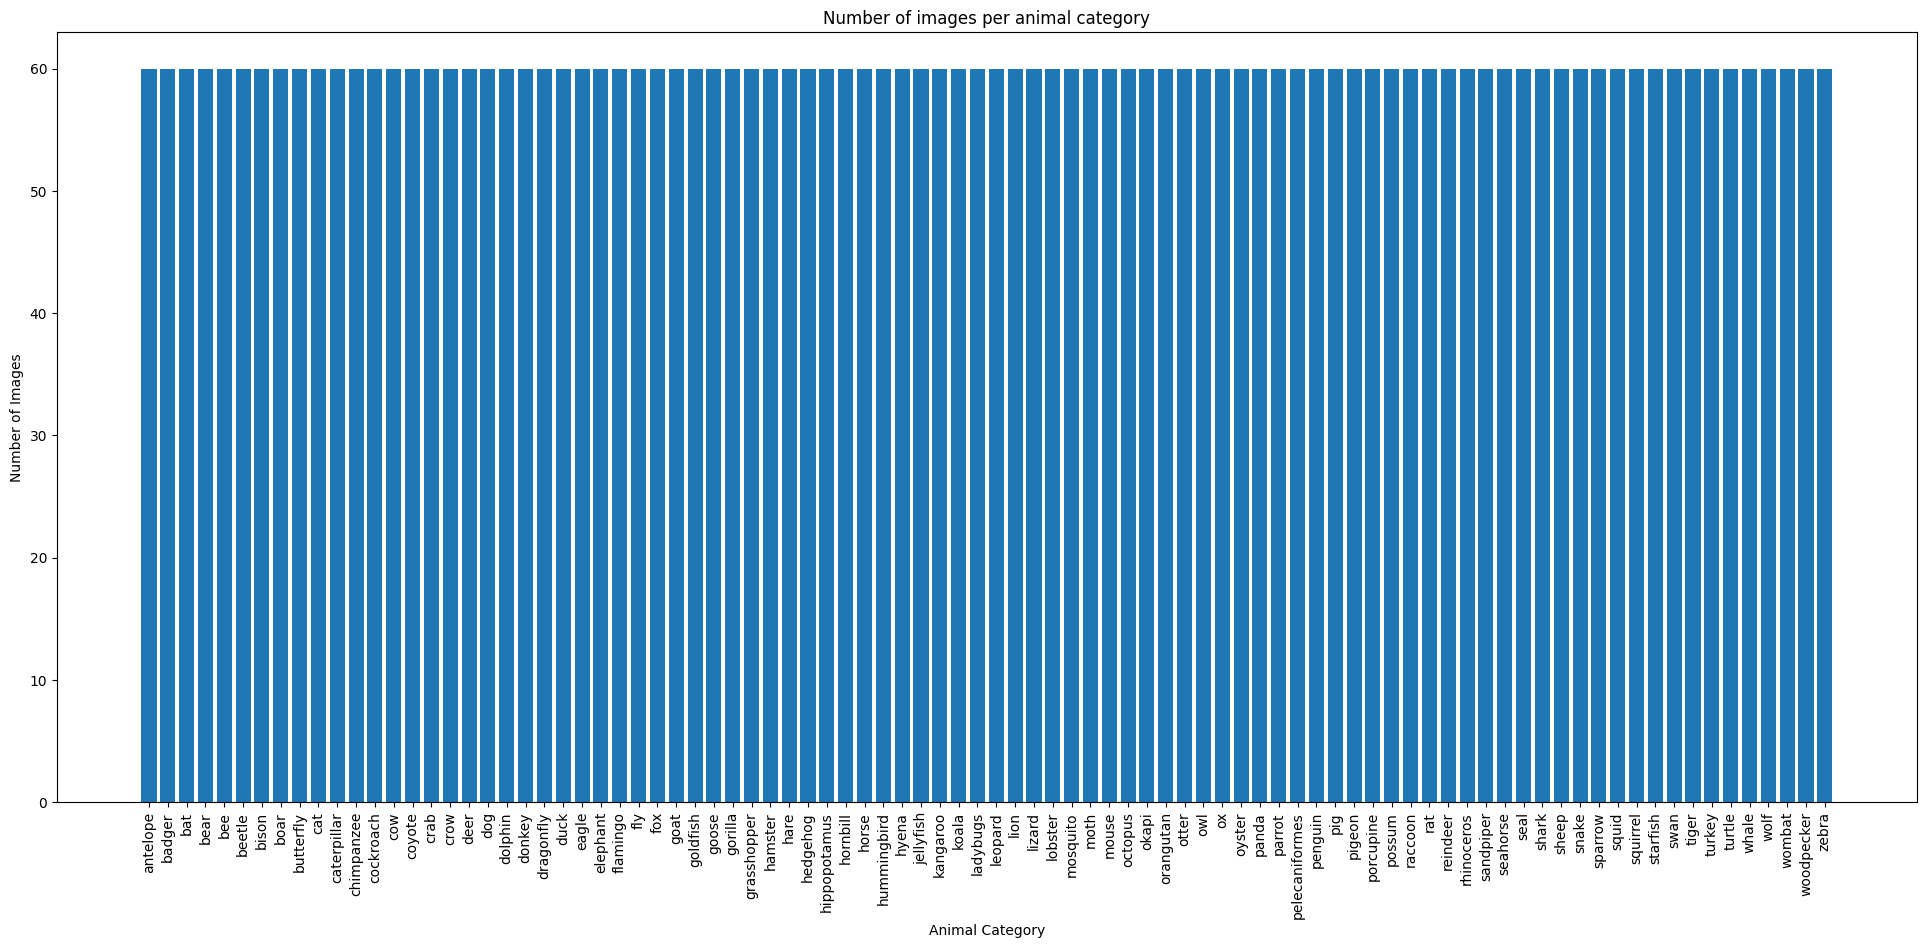

In [13]:
print("Num of images: ", len(list_images))
print("Num of animals: ", len(list_animals))

plt.figure(figsize=(24, 10))
plt.bar(animal_images.keys(), [len(v) for v in animal_images.values()])
plt.xticks(rotation=90)
plt.title("Number of images per animal category")
plt.xlabel("Animal Category")
plt.ylabel("Number of Images")
plt.show()

In [15]:
def check_image_formats(file_list):
    exts = [os.path.splitext(f)[-1].lower() for f in file_list]
    return Counter(exts)

formats = check_image_formats(list_images)

print("Các loại định dạng ảnh trong list:")
for ext, count in formats.items():
    print(f"{ext}: {count}")

Các loại định dạng ảnh trong list:
.jpg: 5400


## 2. Static size images



In [22]:

def collect_image_sizes(file_list):
  widths, heights = [], []
  for f in file_list:
    try:
      with Image.open(f) as img:
          w, h = img.size
          widths.append(w)
          heights.append(h)
    except Exception as e:
        print(f"Lỗi đọc {f}: {e}")
  return widths, heights

# Ví dụ
widths, heights = collect_image_sizes(list_images)
print(f"Width - Min: {min(widths)}, Max: {max(widths)}, Mean: {sum(widths)/len(widths):.2f}")
print(len(widths), len(heights))

Width - Min: 145, Max: 4928, Mean: 808.59
5400 5400


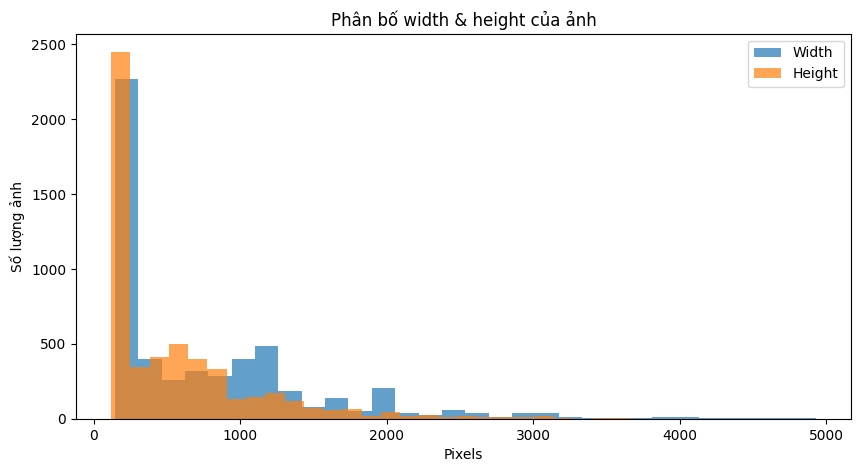

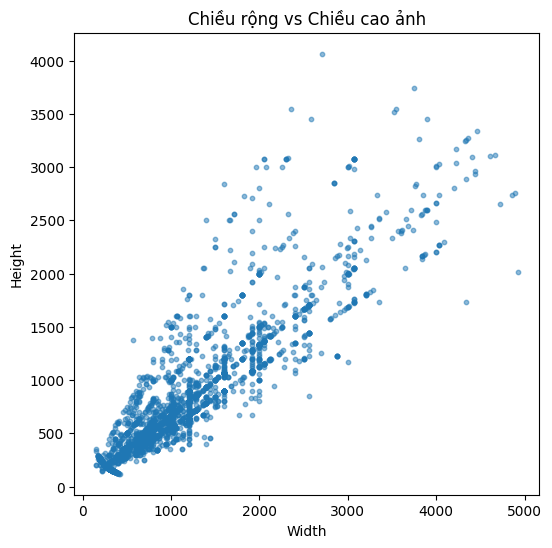

In [23]:
# Histogram phân bố width
plt.figure(figsize=(10,5))
plt.hist(widths, bins=30, alpha=0.7, label="Width")
plt.hist(heights, bins=30, alpha=0.7, label="Height")
plt.legend()
plt.title("Phân bố width & height của ảnh")
plt.xlabel("Pixels")
plt.ylabel("Số lượng ảnh")
plt.show()

# Scatter plot width vs height
plt.figure(figsize=(6,6))
plt.scatter(widths, heights, alpha=0.5, s=10)
plt.title("Chiều rộng vs Chiều cao ảnh")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()


In [ ]:
outline_images = []
rs_images = []

for img in list_images:
  h, w = Image.open(img).size
  if h > 1500 or w > 1500:
    outline_images.append(img)
    continue
  if h < 150 or w < 150:
    outline_images.append(img)
    continue
  rs_images.append(img)

In [35]:
folder_path = "/mnt/c/Users/Admin/Downloads/archive/animals/animals"
list_animals = []
animal_images = {}
list_images = []

for animal in os.listdir(folder_path): 
  path = os.path.join(folder_path, animal)
  animal_path = []
  for img in os.listdir(path):
    image_path = os.path.join(path, img)
    w, h = Image.open(image_path).size
    if h > 1500 or w > 1500:
      continue
    if h < 150 or w < 150:
      continue
    animal_path.append(image_path)

  list_animals.append(animal)
  animal_images[animal] = animal_path
  list_images.extend(animal_path)


Num of images:  4561
Num of animals:  90


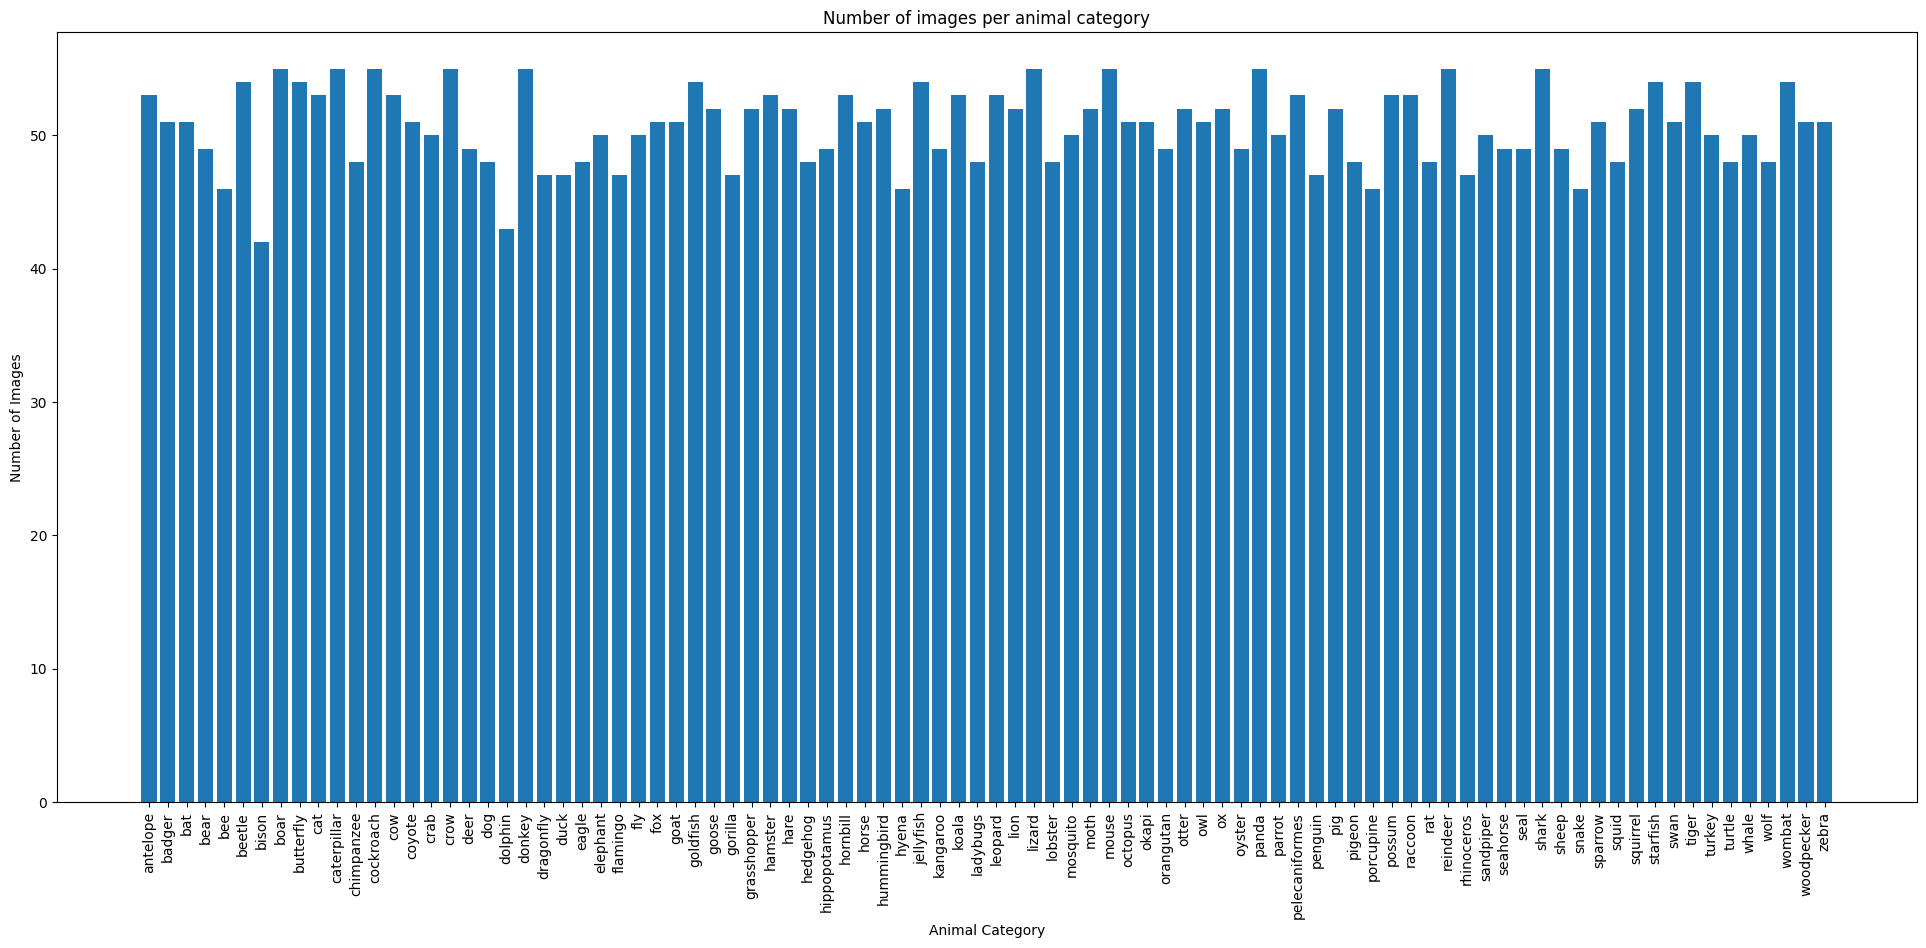

In [36]:
print("Num of images: ", len(list_images))
print("Num of animals: ", len(list_animals))

plt.figure(figsize=(24, 10))
plt.bar(animal_images.keys(), [len(v) for v in animal_images.values()])
plt.xticks(rotation=90)
plt.title("Number of images per animal category")
plt.xlabel("Animal Category")
plt.ylabel("Number of Images")
plt.show()